In [1]:
# Multi-Layer Support Vector Machine (SVM) for Multi-Class Classification on the Iris Dataset with Training Loss Curve Visualization

IMPORT LIBRARIES

In [11]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

CLASS SVM

Number of layers:1
Enter number of neuron15
Iteration 0: loss 2.0002334568118725
Iteration 10: loss 1.9991668624732952
Iteration 20: loss 1.9978756539752822
Iteration 30: loss 1.995904696030238
Iteration 40: loss 1.9928971476858146
Iteration 50: loss 1.9878265051061135
Iteration 60: loss 1.9789104865951586
Iteration 70: loss 1.9629214620325341
Iteration 80: loss 1.933855126913684
Iteration 90: loss 1.880433025780603
Iteration 100: loss 1.7813737621737882
Iteration 110: loss 1.6089709167117243
Iteration 120: loss 1.4818497802043586
Iteration 130: loss 1.3102703389392176
Iteration 140: loss 1.091644702990364
Iteration 150: loss 0.8611677577433419
Iteration 160: loss 0.7466654903871359
Iteration 170: loss 0.6829167256073627
Iteration 180: loss 0.6548940243436492
Iteration 190: loss 0.6348772200213136
Iteration 200: loss 0.6172066448838491
Iteration 210: loss 0.5998312295038074
Iteration 220: loss 0.5815055992906406
Iteration 230: loss 0.5650242204327577
Iteration 240: loss 0.5554195292673

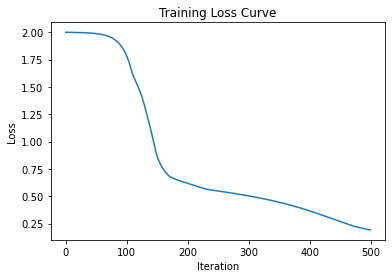

In [38]:
class SVM:
    def __init__(self, num_layers, neurons, num_classes):
        self.num_layers = num_layers
        self.neurons = neurons
        self.num_classes = num_classes
        self.W = [None] * (self.num_layers + 1)
        self.b = [None] * (self.num_layers + 1)
        self.caches = []  
        self.loss_history = []
       
        input_dim = 4  
        for layer in range(self.num_layers):
            if layer == 0:
                input_size = input_dim
            else:
                input_size = self.neurons[layer-1]
            self.W[layer] = 0.01 * np.random.randn(input_size, self.neurons[layer])
            self.b[layer] = np.zeros((1, self.neurons[layer]))
        self.W[self.num_layers] = 0.01 * np.random.randn(self.neurons[-1], self.num_classes)
        self.b[self.num_layers] = np.zeros((1, self.num_classes))

    def affine_forward(self, x, w, b):
        out = np.dot(x, w) + b
        cache = (x, w, b)
        return out, cache

    def relu_forward(self, x):
        out = np.maximum(0, x)
        cache = x
        return out, cache

    def multi_class_SVM_Loss(self, scores, y):
        num_train = scores.shape[0]
        correct_class_scores = scores[np.arange(num_train), y].reshape(-1, 1)
        margins = np.maximum(0, scores - correct_class_scores + 1)
        margins[np.arange(num_train), y] = 0
        loss = np.mean(np.sum(margins, axis=1))
        return loss

    def compute_scores(self, X):
        scores = X
        self.caches = []
        for layer in range(self.num_layers):
            scores, cache = self.affine_forward(scores, self.W[layer], self.b[layer])
            scores, relu_cache = self.relu_forward(scores)
            self.caches.append((cache, relu_cache))
        scores, final_cache = self.affine_forward(scores, self.W[self.num_layers], self.b[self.num_layers])
        self.caches.append((final_cache, None))
        return scores

    def relu_backward(self, dout, cache):
        x = cache
        dx = dout * (x > 0)
        return dx

    def affine_backward(self, dout, cache):
        x, w, b = cache
        dx = np.dot(dout, w.T)
        dw = np.dot(x.T, dout)
        db = np.sum(dout, axis=0, keepdims=True)
        return dx, dw, db

    def gradient_descent(self, X, scores, y, lr):
        num_train = scores.shape[0]
        correct_class_scores = scores[np.arange(num_train), y].reshape(-1, 1)
        margins = np.maximum(0, scores - correct_class_scores + 1)
        margins[np.arange(num_train), y] = 0
        binary = margins > 0
        binary = binary.astype(int)
        row_sum = np.sum(binary, axis=1)
        binary[np.arange(num_train), y] = -row_sum
        dout = binary / num_train  # Gradient of loss
    
        for layer in reversed(range(self.num_layers + 1)):
            
            if layer == self.num_layers:
                dout, dw, db = self.affine_backward(dout, self.caches[layer][0])
            else:
                dout = self.relu_backward(dout, self.caches[layer][1])
                dout, dw, db = self.affine_backward(dout, self.caches[layer][0])
            self.W[layer] -= lr * dw
            self.b[layer] -= lr * db

    def train(self, X, y, learning_rate=0.01, num_iters=100):
        for iteration in range(num_iters):
            scores = self.compute_scores(X)
            loss = self.multi_class_SVM_Loss(scores, y)
            self.loss_history.append(loss)
            if iteration % 10 == 0:
                print(f"Iteration {iteration}: loss {loss}")
            self.gradient_descent(X, scores, y, learning_rate)

    def predict(self, X):
        scores = self.compute_scores(X)
        return np.argmax(scores, axis=1)
    
    def get_weights(self):
        return self.W

layers=int(input("Number of layers:"))
neurons=[]
for i in range(layers):
    neuron=int(input("Enter number of neuron"))
    neurons.append(neuron)
    

iris = datasets.load_iris()
X = iris.data
y = iris.target
num_classes = len(np.unique(y))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

svm_model = SVM(layers,neurons, num_classes)
svm_model.train(X_train, y_train, learning_rate=0.01, num_iters=500)
weights=svm_model.get_weights()
y_pred = svm_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(report)

plt.plot(range(len(svm_model.loss_history)), svm_model.loss_history)
plt.title('Training Loss Curve')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.show()
